In [3]:
import copy

In [4]:
from PIL import Image as PILImage, ImageSequence
from IPython.display import Image as DisplayImage, display
import copy
import os
import numpy as np


def read_gif(path):
    gif = PILImage.open(path)
    frames = [frame.copy().convert("RGBA") for frame in ImageSequence.Iterator(gif)]
    duration = gif.info.get("duration", 100)  # milliseconds per frame
    loop = gif.info.get("loop", 0)
    return frames, duration, loop


def apply_operations(operations, frames):
    result = copy.copy(frames)
    for op in reversed(operations):
        print(op)
        if op[2] == "speed":
            start_frame = op[0]
            end_frame = op[1]
            step = op[3]
            result_0 = result[:start_frame]
            result_op = result[start_frame:end_frame:step]
            result_1 = result[end_frame:]

            print("Len result before operation: ", len(result))
            print("Len result after operation: ", len(result_0 + result_op + result_1))

            result = result_0 + result_op + result_1

    return result


def resize_frames(frames, scale=0.5):
    w, h = frames[0].size
    new_size = (int(w * scale), int(h * scale))

    return [frame.resize(new_size, resample=PILImage.LANCZOS) for frame in frames]


def save_gif(frames, output_path, duration=100, loop=0):
    if not frames:
        raise ValueError("No frames to save.")

    # GIF works best in palette mode
    gif_frames = frames

    gif_frames[0].save(
        output_path,
        save_all=True,
        append_images=gif_frames[1:],
        duration=duration,
        loop=loop,
        disposal=2,
        optimize=True,
    )

    return output_path


def save_webp(frames, output_path, duration=100):
    if not frames:
        raise ValueError("No frames")

    rgb_frames = [f.convert("RGB") for f in frames]

    rgb_frames[0].save(
        output_path,
        save_all=True,
        append_images=rgb_frames[1:],
        duration=duration,
        loop=0,
        format="WEBP",
        lossless=False,
        quality=80,  # adjust 50–90
    )

    return output_path

In [ ]:
input_path = "raw_gif/demo1_full.gif"
operations = [
    (0, 120, "speed", 1),
    (120, 140, "speed", 1),
    (140, 200, "speed", 4),
    (200, 767, "speed", 50),
    (767, 843, "speed", 2),
]

output_path = "demo1_edited.gif"
output_path_webp = "demo1_edited.webp"
frames, duration, loop = read_gif(input_path)

frames = resize_frames(frames, 0.30)
print("Current duration: ", duration, "Current frames: ", len(frames))
new_frames = apply_operations(operations, frames)
new_duration = duration * len(new_frames) / len(frames) + 20
new = int(new_duration)
print("New duration: ", new_duration, "New frames: ", len(new_frames))
save_webp(new_frames, "edited_gif/" + output_path_webp, duration=int(new_duration))

# Gif 2

In [36]:
input_path = "raw_gif/demo2_full.gif"

output_path = "edited_gif/demo2_edited.webp"
frames, duration, loop = read_gif(input_path)


In [37]:
operations = [
    (0, 45, "speed", 2),
    (45, 70, "speed", 1),
    (70, 120, "speed", 2),
    (70, 120, "speed", 2),
    (70, 2500, "speed", 30),
    (2500, 3654, "speed", 20),
]


In [38]:
frames = resize_frames(frames, 0.5)
new_frames = apply_operations(operations, frames)
new_duration = duration * len(new_frames) / len(frames)
new = int(new_duration)
save_webp(new_frames, output_path, duration=int(new_duration))

(2500, 3654, 'speed', 20)
Len result before operation:  3655
Len result after operation:  2559
(70, 2500, 'speed', 30)
Len result before operation:  2559
Len result after operation:  210
(70, 120, 'speed', 2)
Len result before operation:  210
Len result after operation:  185
(70, 120, 'speed', 2)
Len result before operation:  185
Len result after operation:  160
(45, 70, 'speed', 1)
Len result before operation:  160
Len result after operation:  160
(0, 45, 'speed', 2)
Len result before operation:  160
Len result after operation:  138


'edited_gif/demo2_edited.webp'

# Gif 3

In [39]:
input_path = "raw_gif/demo3_full.gif"

output_path = "edited_gif/demo3_edited.webp"
frames, duration, loop = read_gif(input_path)


In [40]:
operations = [
    (0, 30, "speed", 2),
    (30, 80, "speed", 1),
    (30, 228, "speed", 1),
]

In [41]:
frames = resize_frames(frames, 0.5)
new_frames = apply_operations(operations, frames)
new_duration = duration * len(new_frames) / len(frames)
new = int(new_duration)
save_webp(new_frames, output_path, duration=int(new_duration))

(30, 228, 'speed', 1)
Len result before operation:  229
Len result after operation:  229
(30, 80, 'speed', 1)
Len result before operation:  229
Len result after operation:  229
(0, 30, 'speed', 2)
Len result before operation:  229
Len result after operation:  214


'edited_gif/demo3_edited.webp'

# Gif 4

In [45]:
input_path = "raw_gif/demo4_full.gif"

output_path = "edited_gif/demo4_edited.webp"
frames, duration, loop = read_gif(input_path)
frames = frames[50:]

In [46]:
len(frames)

886

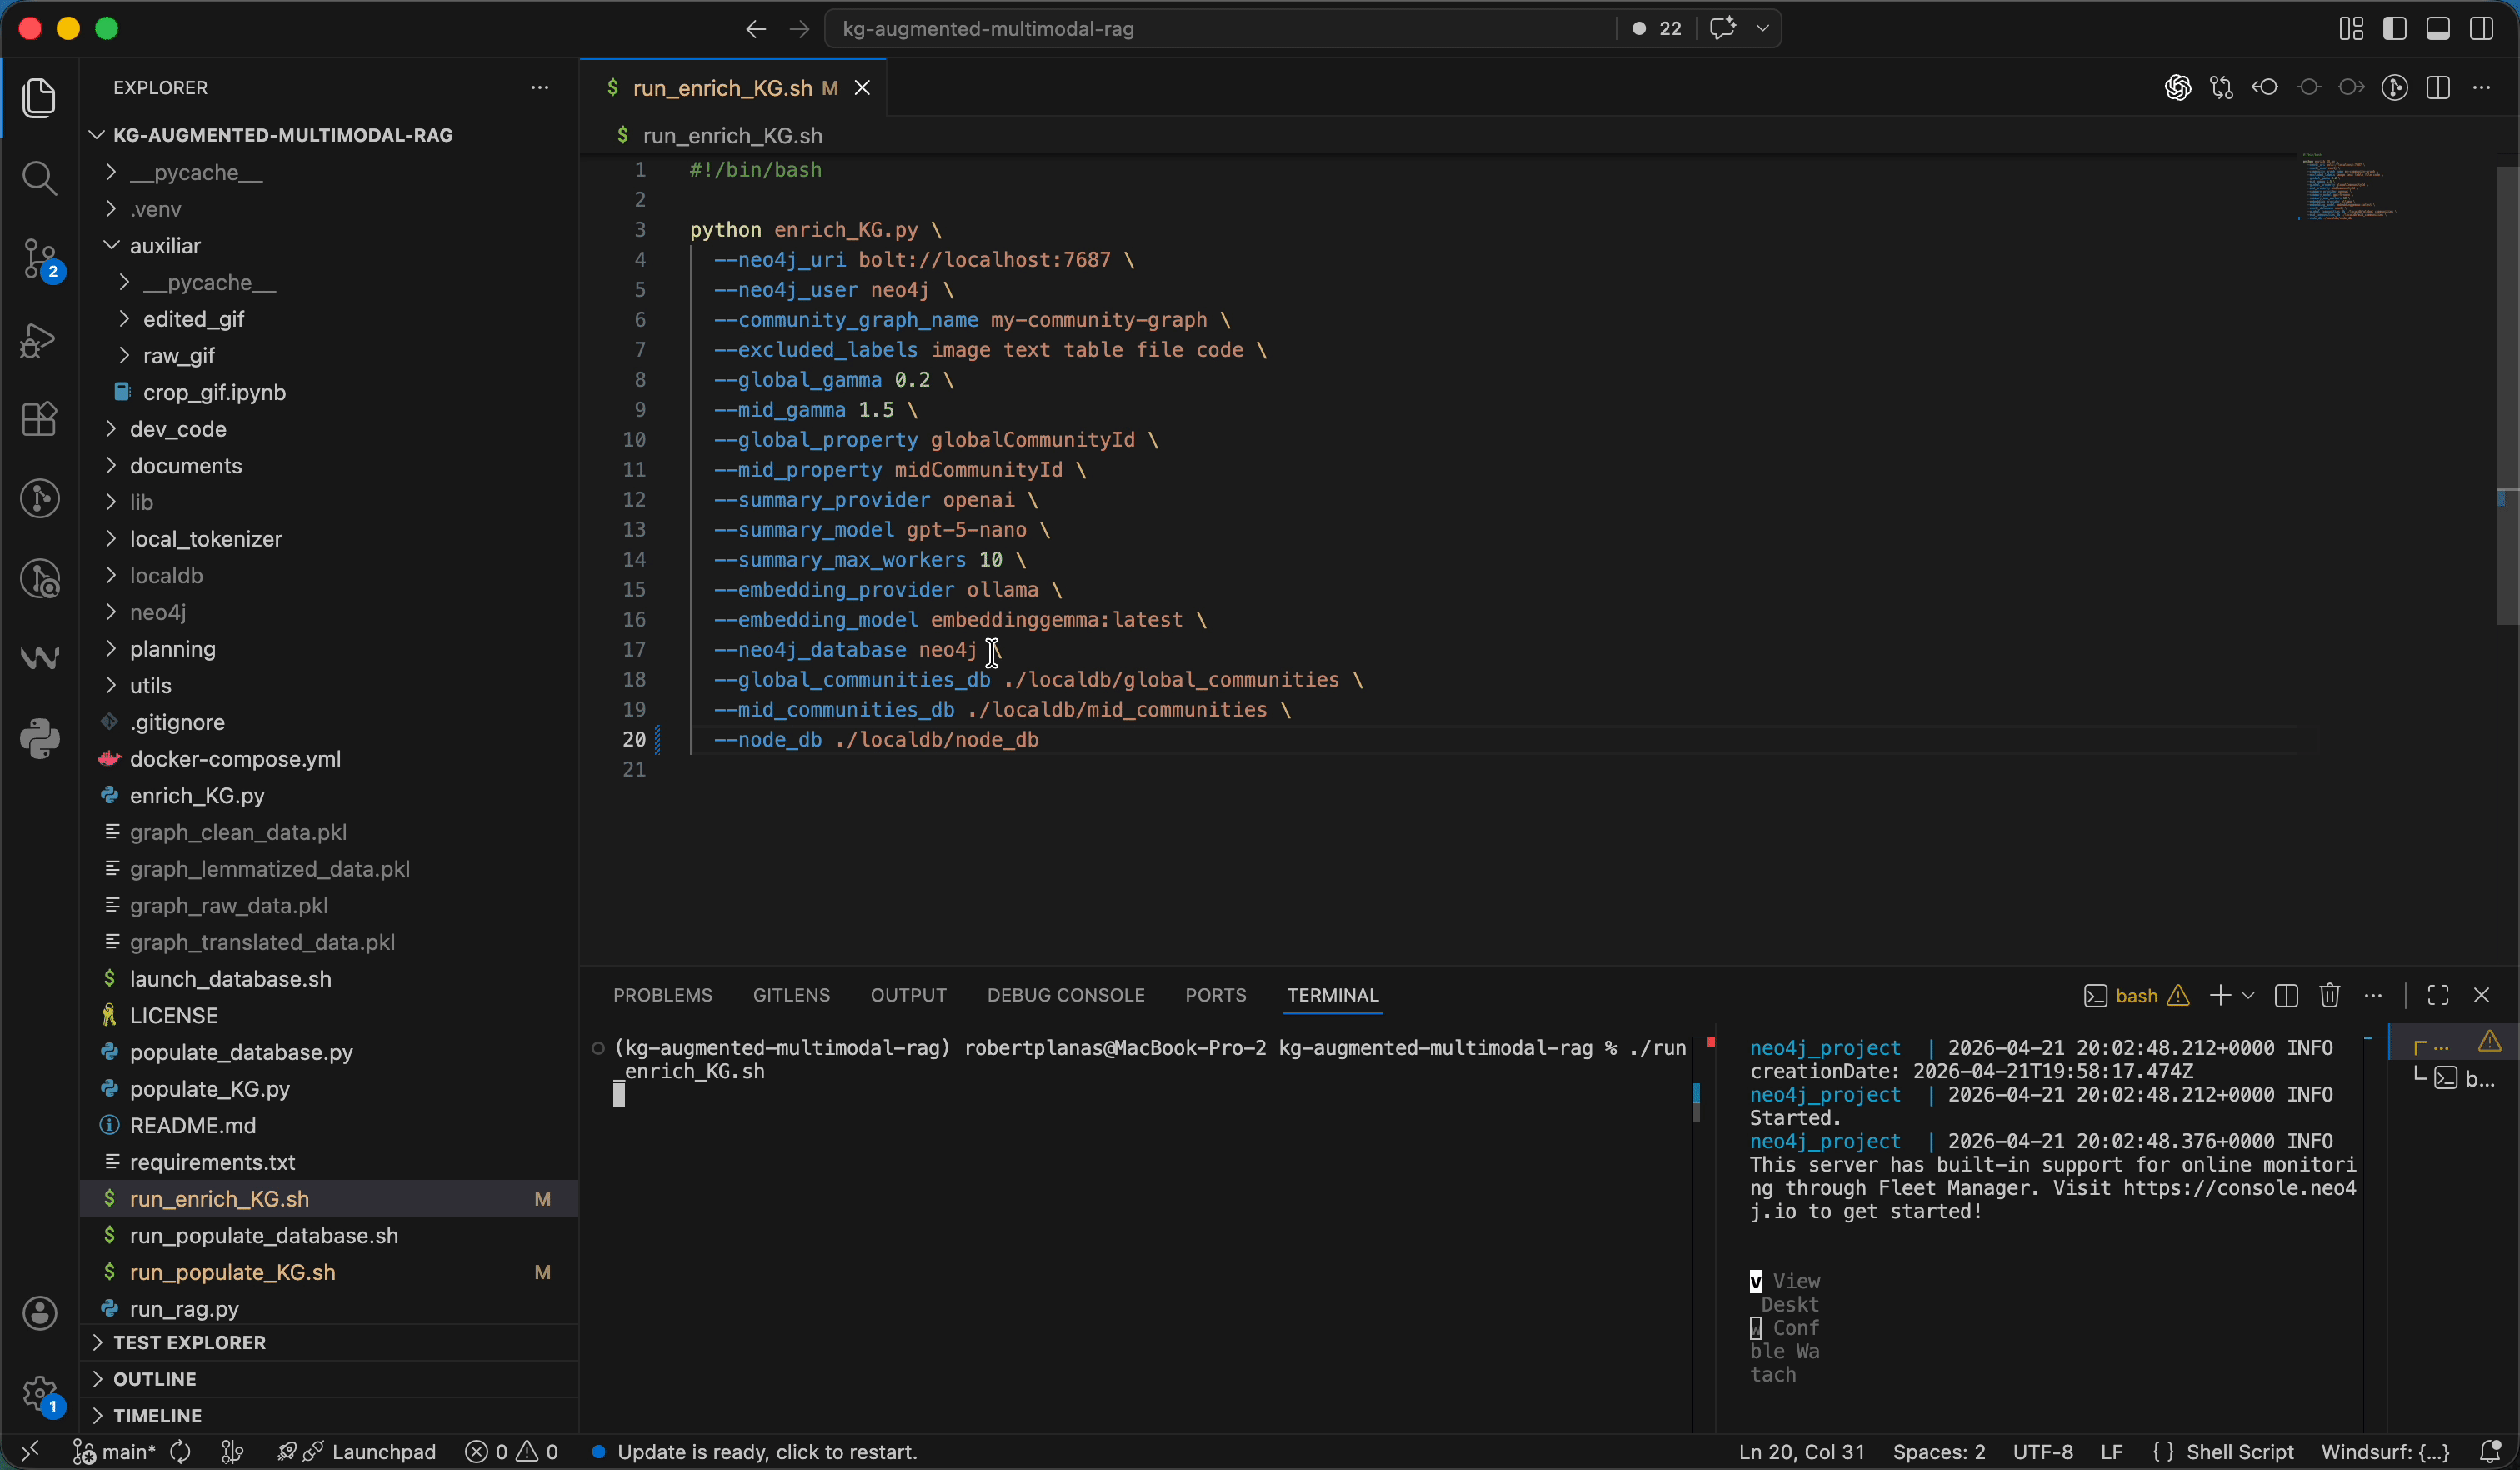

In [47]:
frames[50]

In [48]:
operations = [
    (0, 60, "speed", 1),
    (60, 885, "speed", 5),
]

In [49]:
frames = resize_frames(frames, 0.5)
new_frames = apply_operations(operations, frames)
new_duration = duration * len(new_frames) / len(frames)
new = int(new_duration)
save_webp(new_frames, output_path, duration=int(new_duration))

(60, 885, 'speed', 5)
Len result before operation:  886
Len result after operation:  226
(0, 60, 'speed', 1)
Len result before operation:  226
Len result after operation:  226


'edited_gif/demo4_edited.webp'

# Demo final

In [50]:
input_path = "raw_gif/demo_final.gif"

output_path = "edited_gif/demo_final_edited.webp"
frames, duration, loop = read_gif(input_path)

In [51]:
operations = [
    (105, 420, "speed", 4),
    (420, 621, "speed", 2),
]

In [52]:
frames = resize_frames(frames, 0.5)
new_frames = apply_operations(operations, frames)
new_duration = duration * len(new_frames) / len(frames)
new = int(new_duration)
save_webp(new_frames, output_path, duration=int(new_duration))

(420, 621, 'speed', 2)
Len result before operation:  621
Len result after operation:  521
(105, 420, 'speed', 4)
Len result before operation:  521
Len result after operation:  285


'edited_gif/demo_final_edited.webp'